# Introduction
Time series occur throughout the natural and human worlds, and machine learning and deep learning methods, in addition to more traditional statistical learning methods, are improving our abilities to model and forecast from the data. 

The dynamical systems approach suggests that we look at a univariate time series as measurements, however degraded, of an underlying multi-dimensional system--or rather, as projections onto one dimension what were phase-space points in a higher dimension. The Takens Theorem (1981) guarantees, under some mild conditions, that by using some embedding function, we can embed reconstruct the dynamics of the underlying system (up to diffeomorphism) if we use delay coordinates, meaning that we use lagged values of the time series as features. 

However, the question of how many lags, and which lags to use, remains. We have to estimate the embedding dimension (number of lags) and the 'tau' or delay amount. We could downsample our time series, taking out every other point, and then take five of those to regress on. 

We use the false nearest neighbors (FNN) and averaged false neighbor (AFN)  methods to determine what the embedding dimension and delay amount should be. 

The Average Mutual Information is a information-theoretic concept that works like a nonlinear autocorrelation function. 

We look for the first local min of the AMI--and it looks like it's about 11 or 12. This means that, on average, we can learn something 11 steps into the future by knowing the value in the present. Using delays that are too high results in irrelevance, while taking delays that are too close to each other results in redundance. We have to balance them. 

So rather than taking every 11th point say 5 times, we take the embedding window as M*tau = 55. We must use some method of (non)linear dimensionality reduction to somehow get 5 dimension or features from these points.

In this study, we used the Kernal PCA (KPCA) method, which uses kernel functions to perform nonlinear transforms of the data. We convert the time lags into Hankel matrix with rows of length 55. Using 5 as an low estimate of the required embedding dimension, we keep only the first 5 singular values for their ability to capture most of the variance in the data. The drop off in singular values suggests that we can develop a smaller, more parsimonious model in this fashion. 





In [0]:
!pip install git+https://github.com/manu-mannattil/nolitsa.git
!pip install yfinance --upgrade --no-cache-dir
!pip install ta 
!pip install nolds
!pip install finta
!pip install pyts
!pip install -U git+https://github.com/dmbee/seglearn.git
#!pip install keras-self-attention

#!pip install pydmd
##!pip install EMD-signal
#!pip install pyitlib



  Cloning https://github.com/manu-mannattil/nolitsa.git to /tmp/pip-req-build-y23s0mra
  Running command git clone -q https://github.com/manu-mannattil/nolitsa.git /tmp/pip-req-build-y23s0mra
  Created wheel for nolitsa: filename=nolitsa-0.1-cp36-none-any.whl size=31134 sha256=ca1afa337093438a9332a3beb454e6efb26c080177fc6e919085e964fe6bbd83
  Stored in directory: /tmp/pip-ephem-wheel-cache-kmkykb5f/wheels/9b/2e/49/14f1c7a1b4acd6716bb946b6b40d722c4be76fd0e5b1ade611
Successfully built nolitsa
  Created wheel for yfinance: filename=yfinance-0.1.54-py2.py3-none-any.whl size=22411 sha256=c0c4bf77da768e0d6db20a1aa9f6a353f598c9ddcca91ded097ef681e863e26b
  Stored in directory: /tmp/pip-ephem-wheel-cache-rxs44ykp/wheels/f9/e3/5b/ec24dd2984b12d61e0abf26289746c2436a0e7844f26f2515c
Successfully built yfinance
  Created wheel for ta: filename=ta-0.5.11-cp36-none-any.whl size=23029 sha256=4d8cc4eea6b57958a77aca4e262f8f225d4a7e00dde9be693300dfef5dd15206
  Stored in directory: /root/.cache/pip/wheels/

In [0]:
from ta.momentum import *
from matplotlib import pyplot as plt 
from ta.others import * 

from ta.volume import * 
from ta.volatility import * 
from ta.trend import * 
from ta.momentum import * 

from finta import TA
import yfinance as yf

from nolitsa.delay import * 
from nolitsa.utils import * 

from seglearn.feature_functions import all_features
from seglearn.transform import FeatureRep



from seglearn.tests.test_pipe import regression_test
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from pyts.decomposition import SingularSpectrumAnalysis 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import * 
from sklearn.metrics import * 
from sklearn.decomposition import * 
from sklearn.multioutput import MultiOutputRegressor

from sklearn.linear_model import *
reg = Ridge()


In [0]:
teststock = yf.Ticker("SPY")
start = "2000-01-01"
end = "2017-01-01"

st = teststock.history(period = '10y') #start = start,end = end)
st = st[["Close","Open","Volume","High","Low"]]
st.columns = ["close","open","volume","high","low"]
#st  

In [0]:
logs = pd.Series(daily_log_return(st["close"], fillna=False), name = "LOG") ; st = st.join(logs)

for p in [5]:
  trixi = pd.Series(trix(st["close"], n = p), name = "TRIXI" + str(p)) ; st = st.join(trixi)

will = pd.Series(wr(st['high'], st['low'], st['close'], lbp=14, fillna=False), name = "WR")
st = st.join(will)

macd = pd.Series(macd_diff(st['close'], n_fast=12, n_slow=26, n_sign=9, fillna=False), name = "MACD")
st = st.join(macd)

cmo = pd.Series(TA.VAMA(st), name = "VAMA")
st = st.join(cmo)

cmo = pd.Series(TA.KAMA(st), name = "KAMA")
st = st.join(cmo)

cmo = pd.Series(TA.ROC(st), name = "ROC")
st = st.join(cmo)

cmo = pd.Series(TA.MOM(st), name = "MOM")
st = st.join(cmo)

cmo = pd.Series(TA.RSI(st), name = "RSI")
st = st.join(cmo)

st.dropna(inplace = True)

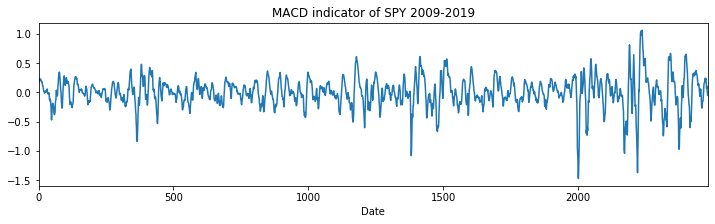

In [0]:
plt.figure(figsize=(12,3))
kac = st['MACD'].values

plt.plot(kac/2)
plt.title("MACD indicator of SPY 2009-2019")
plt.xlabel("Date")
plt.xlim(0,len(kac))
plt.show()


In [0]:
tr = (kac/2) 
tr.shape

(2483,)

[6.51953123 2.95229602 2.60669821 2.41471844 2.32702395 2.25840159
 2.25975895 2.22786978 2.23526117 2.21915833 2.21881435 2.23218203
 2.19863674 2.20950793 2.2280657 ]


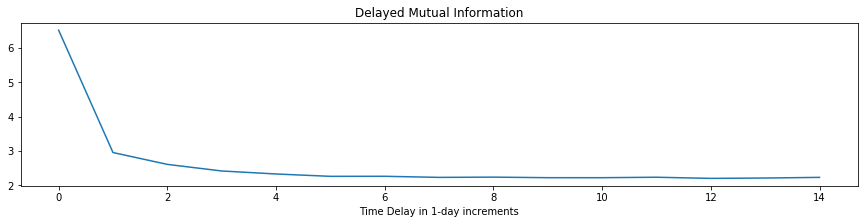

2.1986367412398478
(array([12]),)


In [0]:
dm = dmi(tr, maxtau = 15, bins = 256)
print(dm)
plt.figure(figsize=(15,3))
plt.title("Delayed Mutual Information")
plt.xlabel("Time Delay in 1-day increments")
plt.plot(dm)
plt.show()
print(np.min(dm))
print(np.where(dm == np.min(dm)))

In [0]:
from nolitsa.dimension import * 
e1, e2 = afn(tr, dim=np.arange(2,10), tau=11, metric='chebyshev', window=20, maxnum=None,
        parallel=True)
print(e1,e2)


[49.91261626 10.45640457  4.93290082  3.135333    2.34474161  2.00522591
  1.78406445  1.62176458] [0.23952899 0.25875116 0.25769179 0.24711294 0.24230881 0.24210188
 0.24223993 0.24379338]


[208.37818484  40.41104481  19.14263832  12.68785451   9.67666684
   8.28257063   7.36486531   6.65220937]
2483


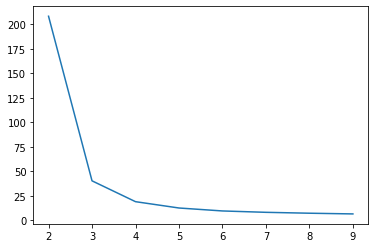

In [0]:
print(e1/e2)
plt.plot(list(np.arange(2,10)), list(e1/e2))

print(len(tr))

In [0]:
from nolitsa.dimension import * 
for i in range(3,16):
      print("embedding dimension = %s" % i, fnn(tr, 
                dim=[i], 
                tau = 11, 
                R=10.0, A=2.0, 
                metric = 'euclidean', window = 200,
                maxnum = 100, parallel=True))

embedding dimension = 3 [[0.24326531]
 [0.14204082]
 [0.31346939]]
embedding dimension = 4 [[0.06355064]
 [0.15211152]
 [0.18245182]]
embedding dimension = 5 [[0.01359143]
 [0.17998353]
 [0.18204283]]
embedding dimension = 6 [[0.00082747]
 [0.21141911]
 [0.21224659]]
embedding dimension = 7 [[0.        ]
 [0.24355777]
 [0.24355777]]
embedding dimension = 8 [[0.        ]
 [0.29436326]
 [0.29436326]]
embedding dimension = 9 [[0.        ]
 [0.33347315]
 [0.33347315]]
embedding dimension = 10 [[0.        ]
 [0.38010957]
 [0.38010957]]
embedding dimension = 11 [[0.        ]
 [0.42464014]
 [0.42464014]]
embedding dimension = 12 [[0.        ]
 [0.48745215]
 [0.48745215]]
embedding dimension = 13 [[0.       ]
 [0.5474359]
 [0.5474359]]
embedding dimension = 14 [[0.        ]
 [0.61270932]
 [0.61270932]]
embedding dimension = 15 [[0.        ]
 [0.72088007]
 [0.72088007]]


In [0]:

from statsmodels.tsa.stattools import adfuller
adfuller(tr, maxlag = 60, regression=None, autolag='AIC', store=False, regresults=True)

(-12.1507163744612,
 3.696784997030947e-22,
 {'1%': -2.566648721849117,
  '10%': -1.6167125662759247,
  '5%': -1.94110965135008},
 <statsmodels.tsa.stattools.ResultsStore at 0x7fc1ac00abe0>)

In [0]:
from nolitsa.utils import * 
print(statcheck(tr))




In [0]:

from nolds import * 
print(lyap_e(tr, emb_dim = 4, matrix_dim = 4, min_nb=None, min_tsep=0, tau=10,
           debug_plot=False, debug_data=False, plot_file=None))
#print(lyap_r(tr))
#print(hurst_rs(tr))

[ 0.04641506  0.00920602 -0.01918115 -0.07281893]


In [0]:
forecast = 0 
dim = 55; tau = 1
skip = 0
ip = reconstruct(tr, dim = dim, tau = tau )
pd.DataFrame(ip)
X = ip[: ,:] ; Y = ip[:,:]
# print(X.shape, Y.shape)

# Training Model


(2430, 2, 55)


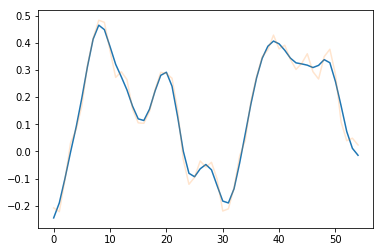

In [0]:

ssa = SingularSpectrumAnalysis(window_size=5,groups=2)
X_ssa = ssa.fit_transform(X=X)
print(X_ssa.shape)
X_ssa2 = X_ssa[:,0,:]
plt.plot(X_ssa2[440])
plt.plot(X[440], alpha = 0.2)

In [0]:
sstrainX, ssvalX = train_test_split(X_ssa2, shuffle = False, test_size = 0.05)


In [0]:
transformer = KernelPCA(n_components = 5, kernel='rbf', fit_inverse_transform=True, random_state = 33, remove_zero_eig= True)
trainX_transformed = transformer.fit_transform(sstrainX)
print(trainX_transformed.shape)
print(np.round(transformer.lambdas_,1))

(2307, 5)
[44.6 43.8 30.  23.9 17.6]


In [0]:
np.cumsum(transformer.lambdas_)/np.sum(transformer.lambdas_)

array([0.27929689, 0.55299073, 0.74082887, 0.89016422, 1.        ])

In [0]:
from nolds import * 
print(lyap_e(trainX_transformed[:,0], emb_dim = 5, matrix_dim = 5, min_nb=None, min_tsep=0, tau=10,
           debug_plot=False, debug_data=False, plot_file=None))

[ 0.01214607  0.00202248 -0.01249768 -0.03400298 -0.07853751]


In [0]:
skips = 5
trunc = None
xx = trainX_transformed[:-skips,:trunc]
yy = trainX_transformed[skips:,:trunc]


0.9842640694937723


/usr/local/lib/python3.6/dist-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/base.py:420: FutureWarning: The default value of multioutput (not exposed in score method) will change from 'variance_weighted' to 'uniform_average' in 0.23 to keep consistent with 'metrics.r2_score'. To specify the default value manually and avoid the warning, please either call 'metrics.r2_score' directly or make a custom scorer with 'metrics.make_scorer' (the built-in scorer 'r2' uses multioutput='uniform_average').
  "multioutput='uniform_average').", FutureWarning)


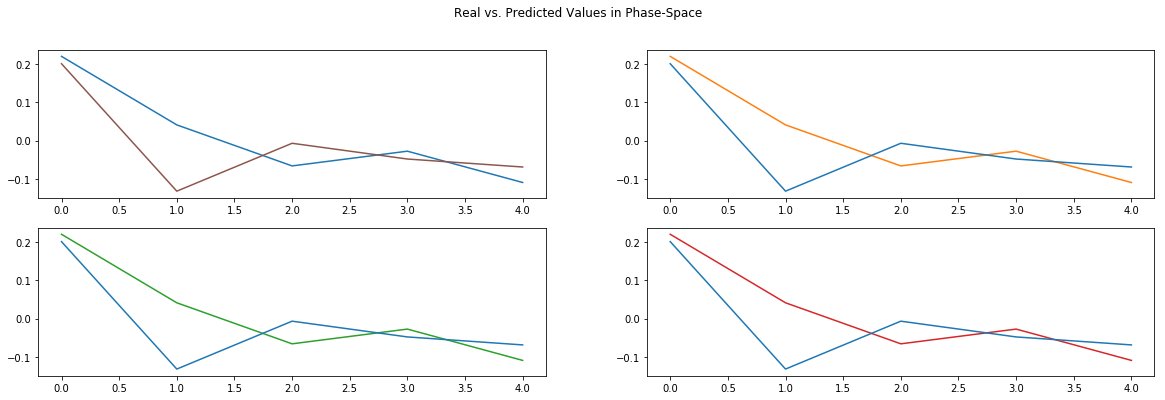

In [0]:

reg = MultiTaskLasso(1e-5)
reg = RandomForestRegressor()
reg.fit(xx, yy)
print(reg.score(xx,yy))  #,reg.score(valX, valY))
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20,6))
fig.suptitle('Real vs. Predicted Values in Phase-Space')

ax1.plot(reg.predict(xx)[j],'tab:blue')
ax1.plot(xx[j,:],'tab:brown')


ax2.plot(reg.predict(xx)[j], 'tab:orange')
ax2.plot(xx[j,:])
ax3.plot(reg.predict(xx)[j], 'tab:green')
ax3.plot(xx[j,:])
ax4.plot(reg.predict(xx)[j], 'tab:red')
ax4.plot(xx[j,:])


/usr/local/lib/python3.6/dist-packages/sklearn/base.py:420: FutureWarning: The default value of multioutput (not exposed in score method) will change from 'variance_weighted' to 'uniform_average' in 0.23 to keep consistent with 'metrics.r2_score'. To specify the default value manually and avoid the warning, please either call 'metrics.r2_score' directly or make a custom scorer with 'metrics.make_scorer' (the built-in scorer 'r2' uses multioutput='uniform_average').
  "multioutput='uniform_average').", FutureWarning)


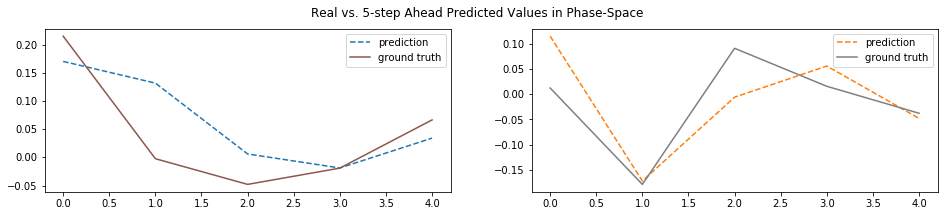

In [0]:
vxx = transformer.transform(ssvalX[:-skips,:])
vyy = transformer.transform(ssvalX[skips:,:])
reg.score(vxx,vyy)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16,3))
fig.suptitle('Real vs. 5-step Ahead Predicted Values in Phase-Space')

j = np.random.randint(0,len(vxx) - skip)
ax1.plot(reg.predict(xx)[j],'tab:blue', label = 'prediction', linestyle='dashed')
ax1.plot(xx[j,:],'tab:brown', label = 'ground truth')
ax1.legend()


j = np.random.randint(0,len(vxx) - skip)
ax2.plot(reg.predict(xx)[j], 'tab:orange', label = 'prediction',linestyle='dashed')
ax2.plot(xx[j,:], 'tab:gray',label = 'ground truth')
ax2.legend()
  



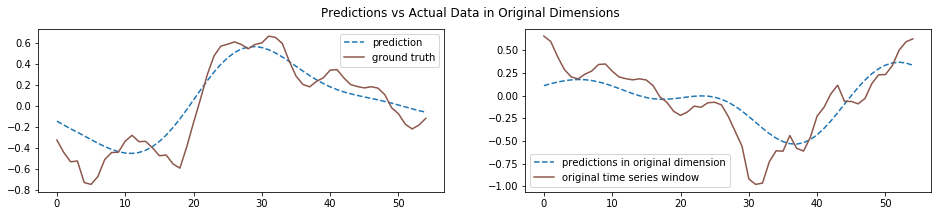

In [0]:
od_preds = transformer.inverse_transform(reg.predict(vxx))
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16,3))
fig.suptitle('Predictions vs Actual Data in Original Dimensions')

j = np.random.randint(0,len(vxx) - skip)
ax1.plot(od_preds[j],'tab:blue', linestyle = 'dashed', label = "prediction")
ax1.plot(X[-len(vyy):,:][j], 'tab:brown', label = "ground truth")
ax1.legend()


j = np.random.randint(0,len(vxx) - skip)
ax2.plot(od_preds[j], 'tab:blue', linestyle='dashed', label = 'predictions in original dimension',)
ax2.plot(X[-len(vyy):,:][j], 'tab:brown', label = 'original time series window')
ax2.legend()



# Misc.

In [0]:

from keras.layers import * 
from keras.models import * 
from keras.optimizers import * 
from keras.regularizers import *
from keras.callbacks import *
from keras.initializers import * 
#!pip install keras-tcn


#from keras_self_attention import SeqSelfAttention

import numpy
import tensorflow

from keras.constraints import Constraint
from tensorflow.linalg import expm


class Skew(Constraint):

    

    def __init__(self, axis=None, orthonormal=False):
        self.axis = axis
        self.orthonormal = orthonormal

    def __call__(self, w):
        if self.axis is None:
            self.axis = list(range(len(w.shape) - 1))
        elif type(self.axis) == int:
            self.axis = [self.axis]
        else:
            self.axis = numpy.asarray(self.axis, dtype='uint8')
        self.axis = list(self.axis)

        bob = w
        diags =  tf.matrix_band_part(bob, 0, 0)
        up = tf.matrix_band_part(bob, -1,0) - diags
        up_trans = tf.transpose(up)
        w_final = diags + up + up_trans
        return w_final 


    def get_config(self):
        return {'axis': self.axis,
                'orthonormal': self.orthonormal}

from keras.constraints import *
es = EarlyStopping(monitor='val_loss', 
                  min_delta = 1e-4, patience = 15, 
                  verbose=0, mode='auto', 
                  baseline=None, restore_best_weights=True)

reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=10, verbose=0, 
                           mode='auto', min_delta=1e-3, cooldown=0, min_lr=1e-5)
from keras.layers import Input, RepeatVector, CuDNNGRU, CuDNNLSTM
ker = 1e-4
act = 1e-4


i = Input((sstrainX.shape[-1],))
out = Dense(30, kernel_initializer = 'glorot_uniform',
            use_bias = False)(i)

out = Dense(5, kernel_initializer = 'glorot_uniform',
            use_bias = False)(out)



out = Dense(5, 
            kernel_regularizer = l1_l2(l1 = 3e-5, l2 = 1e-8),
            kernel_initializer='Identity', 
            use_bias = False, 
            name = "Koopman",
            kernel_constraint = Skew())(out) #kernel_constraint=Skew(orthonormal=True))(i)


out = Dense(30, kernel_initializer = 'glorot_uniform',
            use_bias = False)(out)

out = Dense(55, use_bias = False)(out)



model = Model(inputs = [i], outputs = out, name = 'Auto-Encoder')



model.compile(loss = "mse", metrics = [], 
              optimizer = Adam(lr = 1e-3))

for l in model.layers[:]:
  l.trainable = True
  
model.summary()



model.layers[-3].trainable = False
model.summary()
model.reset_states()  
steps = 1
skips = 1
skip = False
if skip == False:
        model.fit(sstrainX[:-skips:,:], sstrainX[skips:,:],
        validation_split = 0.10,
        shuffle = True, 
        callbacks = [es, reduce],
        batch_size = 256,
        epochs = 800)

else:
   model.fit(sstrainX, sstrainX,
        validation_split = 0.02,
        shuffle = True, 
        callbacks = [es, reduce],
        batch_size = 32,
        epochs = 800)
  
modelE = Model(inputs = model.inputs, outputs = model.layers[3].output, name = "y1mod")
modelE.summary()

modelE2 = Model(inputs = model.inputs, outputs = model.layers[2].output, name = "y0mod")
modelE2.summary()


i1 = Input((55,))
i2 = Input((55,))
out1 = model.layers[1](i1)
out1 = model.layers[2](out1)
o1 = model.layers[3](out1)

out2 = model.layers[1](i2)
o2 = model.layers[2](out2)

diff = concatenate([o1, o2])

diff = Dense(5, kernel_regularizer  = l1(1e-6))(diff)

mm = Model(inputs = [i1,i2], outputs = diff)

mm.compile(loss = 'mse', optimizer = Adam())
for lay in mm.layers:
  lay.trainable = True
mm.summary()
mm.fit([sstrainX[:-1,:], sstrainX[1:,:]],
       np.zeros((sstrainX[:-1,:].shape[0],5)),
       validation_split = 0.03,
       epochs = 200,
       shuffle = True,
       callbacks = [reduce, es])


inn = Input((55,))
out = inn 
for i in range(1,5):
  out = mm.layers[i](out)

out = model.layers[-2](out)
out = model.layers[-1](out)
                              
fin = Model(inputs = [inn], outputs = out)
fin.summary()

for lay in fin.layers[:]:
  lay.trainable=True
skips = 1  
fin.compile(loss = 'mse', optimizer = Adam())
fin.reset_states()



skip = True
if skip == True:
        fin.fit(sstrainX[:-skips:,:], sstrainX[skips:,:],
        validation_split = 0.04,
        shuffle = True, 
        callbacks = [es, reduce],
        batch_size = 32,
        epochs = 800)

koop = fin.layers[-3].get_weights()[0]
pd.DataFrame(koop)
pd.DataFrame(np.round(model.layers[-3].get_weights()[0],4))
import scipy
myeigs = scipy.linalg.eig(koop, right=True)
print(myeigs[1])
for i in range(5):
  plt.plot(myeigs[1][i])
  plt.show()       




Instructions for updating:
Use Variable.read_value. Variables in 2.X are initialized automatically both in eager and graph (inside tf.defun) contexts.

Model: "Auto-Encoder"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 55)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 30)                1650      
_________________________________________________________________
dense_2 (Dense)              (None, 5)                 150       
_________________________________________________________________
Koopman (Dense)              (None, 5)                 25        
_________________________________________________________________
dense_3 (Dense)              (None, 30)                150       
_________________________________________________________________
dense_4 (Dense)              (N